<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T3/semana-02/blob/main/Ciclo_de_Vida_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Problema de negócio

## Situação: Nós fomos contratados pelo Diretor de uma grande empresa de Internet por Fibra Óptica. Na reunião de abertura, ele bate na mesa e diz: 'Estamos quebrando! Todo mês milhares de clientes cancelam o serviço e vão para o concorrente. Precisamos resolver isso!'

## E agora, o que a gente faz?



### Passo 1: Descobrir o Objetivo Real (A Meta)

### Pergunta: o objetivo da nossa IA é fazer o cliente mudar de ideia ou descobrir quem está insatisfeito antes de ele ir embora?

### A explicação: O negócio não quer um relatório do passado dizendo quem já saiu (isso o financeiro já sabe). O objetivo de negócio é a antecipação. Queremos olhar para os clientes atuais e adivinhar quem está com o "pé para fora"

### Passo 2: Traduzir para Machine Learning (A Matemática)

### Pergunta: Como a gente traduz isso para o computador? Isso é um problema de Regressão (adivinhar um número) ou de Classificação (adivinhar uma categoria)?

### A explicação: É um problema de Classificação Binária. O computador vai olhar para um cliente e dar uma etiqueta: 0 (Cliente Seguro / Fica) ou 1 (Alerta de Cancelamento / Churn)

### Passo 3: Mapear os Dados Necessários (O Combustível)

### Pergunta: Para a IA descobrir quem vai cancelar, que tipo de rastro ou comportamento esse cliente deixa antes de tomar a decisão? O que a gente precisa coletar de dados?

### DADOS

#### Tempo de contrato: Um cliente que está há 3 anos na empresa é mais difícil de sair do que um que entrou há 2 meses.

#### Uso do suporte: Se o cara ligou 5 vezes para reclamar da lentidão da internet só neste mês, o alerta dele está vermelho.

# Importando as libs

In [ ]:
#manipulacao de dados
import pandas as pd
import numpy as np

# visualizacao de dados
import matplotlib.pyplot as plt
import seaborn as sns

# separacao do treino e teste
from sklearn.model_selection import train_test_split

# importando modelo de ML
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# importando métricas de avaliação do modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# imputação de dados automaticamente
from sklearn.impute import SimpleImputer

# modelagem de dados categoricos
from sklearn.preprocessing import OneHotEncoder

# 2. Coleta de dados

In [ ]:
# lendo o dataset
df = pd.read_excel('base_internet.xlsx')

# plotando (mostrando na tela) um sample dos dados
df.head()

,meses_contrato,reclamacoes_suporte,atrasos_pagamento,tipo_plano,cancelou
0,12.0,1.0,0.0,Fibra,0
1,2.0,5.0,2.0,Cabo,1
2,24.0,0.0,0.0,Fibra,0
3,1.0,4.0,1.0,Cabo,1
4,6.0,2.0,1.0,Satélite,0


In [ ]:
print(f'analisando o shape (corpo) do dataset (linhas: {df.shape[0]} e colunas: {df.shape[1]})\n')

print(f'\nTipos de dados por coluna:\n {df.dtypes}\n')

print(f'\nEstatisticas descritivas por colunas NUMERICAS:\n {df.describe()}\n')

print(f'\nAnalisando as informações gerais dos dados:\n {df.info()}\n')

print(f'\nAnalisando a quantidade de valores nulos por colunas:\n {df.isnull().sum()}\n')

print(f'\nAnalisando a quantidade de dados duplicados na base:\n {df.duplicated().sum()}')

analisando o shape (corpo) do dataset (linhas: 50 e colunas: 5)


Tipos de dados por coluna:
 meses_contrato         float64
reclamacoes_suporte    float64
atrasos_pagamento      float64
tipo_plano              object
cancelou                 int64
dtype: object


Estatisticas descritivas por colunas NUMERICAS:
        meses_contrato  reclamacoes_suporte  atrasos_pagamento   cancelou
count       48.000000            48.000000          48.000000  50.000000
mean        11.979167             2.708333           0.979167   0.500000
std         12.717034             2.041676           1.061704   0.505076
min          1.000000             0.000000           0.000000   0.000000
25%          2.000000             1.000000           0.000000   0.000000
50%          6.000000             2.500000           1.000000   0.500000
75%         18.250000             4.250000           2.000000   1.000000
max         48.000000             6.000000           3.000000   1.000000

<class 'pandas.core.frame.Da

# 3. Preparação dos dados

## Separação dos X e y - Treino e teste

In [ ]:
X = df.drop(columns=['cancelou'])
y = df['cancelou']

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Limpeza dos dados

In [ ]:
print('linhas com valores nulos:\n')
X_treino[X_treino.isnull().any(axis=1)]

linhas com valores nulos:



,meses_contrato,reclamacoes_suporte,atrasos_pagamento,tipo_plano
41,NaN,5.0,3.0,Satélite
44,9.0,1.0,NaN,Satélite
10,15.0,2.0,NaN,Fibra
20,NaN,0.0,0.0,Fibra
28,13.0,NaN,0.0,Fibra


### Decisão: O que fazer com os dados nulos? Exclui-los ou preenche-los?

##### Opção 1: Remover as linhas com dados nulos (`.dropna()`)
* **Consequências:** Você elimina o registro inteiro da base de dados.
* **Vantagens:** Garante que a IA treinará apenas com dados 100% reais e sem suposições matemáticas feitas por nós.
* **Desvantagens:** **Perda de dados (o maior perigo).** Se você tem uma base pequena (como a nossa de 50 linhas) e deletar 10 linhas, você jogou fora 20% do seu histórico. A IA terá menos exemplos para aprender.
* **Quando usar:** Quando a quantidade de linhas nulas for irrelevante (menos de 1% a 2% da base total) ou quando o dado faltante for o próprio gabarito/target (ex: se falta a coluna se o cliente 'cancelou' ou não, não faz sentido inventar).

In [ ]:
# X_treino_tratado = X_treino.dropna()
# y_treino_tratado = y_treino.loc[X_treino_tratado.index]

# print('Verificando novamente a contagem de valores nulos em X_treino_tratado:\n')
# display(X_treino_tratado.isnull().sum())

# print('verificando o novo shape do X_treino_tratado:\n')
# print(X_treino_tratado.shape, X_treino.shape)

# X_teste_tratado = X_teste.dropna()
# y_teste_tratado = y_teste.loc[X_teste_tratado.index]

# display(X_teste_tratado.isnull().sum())

# print(X_teste_tratado.shape, X_teste.shape)

#### Preencher com algumas estatisticas

##### Opção 2: Preencher os dados nulos (`.fillna()`)
* **Consequências:** Você usa uma estatística (média, mediana ou moda) dos dados passados para "tapar o buraco".
* **Vantagens:** Mantém o tamanho da sua base de dados intacto. A IA não perde as outras informações úteis contidas naquela mesma linha.
* **Desvantagens:** Introduz "ruído" ou dados artificiais. Se você preencher de forma errada, pode distorcer a realidade e fazer a máquina aprender regras falsas.
* **Quando usar:** Quando a base é pequena ou quando o padrão da coluna permite uma substituição segura (como usar a mediana para idades ou meses de contrato).

In [ ]:
# # # 1. Calcula a estatística estritamente no X_treino
# mediana_coluna = X_treino['meses_contrato'].median()

# # # 2. Preenche os nulos no X_test com a média do treino
# X_treino['meses_contrato'] = X_treino['meses_contrato'].fillna(mediana_coluna)

# # # 3. Preenche os nulos no X_test com a média do treino
# X_teste['meses_contrato'] = X_teste['meses_contrato'].fillna(mediana_coluna)

# 1 Criando o imputer com base na mediana do X_treino
imputer = SimpleImputer(strategy='median')

# 2. Ajustar no treino e aplicar
X_treino_tratado = imputer.fit_transform(X_treino.select_dtypes(include=['int64', 'float64']))

# 3. Aplicar no teste (usando a mediana do treino SEM PROBLEMA ALGUM)
X_teste_tratado = imputer.transform(X_teste.select_dtypes(include=['int64','float64']))

# 4. Modelagem

## Get Dummies - Simples

##### `pd.get_dummies` (Abordagem Simples)

*   **O que faz:** Converte variáveis categóricas (texto) em colunas binárias de 0 ou 1. Se a coluna tipo_plano tiver "Fibra", "Cabo" e "Satélite", ele criará três colunas distintas.

*   **Vantagens:** Extremamente simples, rápido e prático para quando você está apenas explorando os dados no início do projeto e quer gerar gráficos rápidos.

O Grande Perigo no Machine Learning: Ele não tem memória. Ele analisa apenas o DataFrame que está na memória naquele exato segundo. Se você aplicá-lo no X_train e depois no X_test separadamente, e por azar o seu X_test não contiver nenhuma linha do plano "Satélite", o get_dummies do teste não vai criar a coluna tipo_plano_Satélite. O seu modelo vai quebrar porque o Treino e o Teste ficaram com formatos desalinhados.

In [ ]:
# #  convertendo o texto em colunas numericas no treino e no teste
# X_treino_final = pd.get_dummies(X_treino, columns=['tipo_plano'], dtype=int)
# X_teste_final = pd.get_dummies(X_teste, columns=['tipo_plano'], dtype=int)

# # garantir que o teste tenha exatamente as mesmas colunas do treino
# X_teste_final = X_teste_final.reindex(columns=X_treino_final.columns, fill_value=0)

# X_treino_final.head()

,meses_contrato,reclamacoes_suporte,atrasos_pagamento,tipo_plano_Cabo,tipo_plano_Fibra,tipo_plano_Satélite
12,48.0,0.0,0.0,0,1,0
4,6.0,2.0,1.0,0,0,1
37,5.0,5.0,1.0,0,0,1
8,18.0,1.0,0.0,0,1,0
3,1.0,4.0,1.0,1,0,0


## OneHotEnconder - Profissional

*   **O que faz:** Realiza exatamente a mesma conversão matemática (One-Hot Encoding), mas funciona como um objeto/estimador programável do Scikit-Learn, contendo os métodos .fit() e .transform().

*   **Vantagens: (O Padrão da Indústria):**

    * **Consistência Absoluta:** Ele garante que os conjuntos de treino e teste tenham sempre as mesmas colunas na mesma ordem, eliminando a necessidade de truques manuais de alinhamento.

    *   **Segurança: em Produção (Deploy):** Configurado com handle_unknown='ignore', se amanhã um cliente novo entrar no aplicativo da empresa com um plano inexistente ou digitado errado, o modelo ignora o erro de forma elegante em vez de mandar o servidor da empresa abaixo.

    *   **Funcionamento:** Você dá o .fit() apenas nos dados de treino para o encoder aprender e "carimbar" quais são as categorias válidas. Depois, você usa o .transform() no treino e no teste para aplicar essa regra rígida.

Pronto para o Mundo Real: Como é um objeto do Sklearn, você consegue salvar o arquivo do OneHotEncoder (num arquivo .pkl) junto com o seu modelo final para criar a API da empresa. O get_dummies não permite isso.

In [ ]:
# 1. instanciar o encoder
encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')

# identificar as colunas numericas do x_treino/x_teste
numeric_cols = X_treino.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_treino.select_dtypes(include=['object']).columns

# ajustando o encoder nos dados de treino (aprender as categorias)
encoder.fit(X_treino[['tipo_plano']])

# transformando a coluna de texto em numericas
colunas_treino_encoded = encoder.transform(X_treino[['tipo_plano']])
colunas_teste_encoded = encoder.transform(X_teste[['tipo_plano']])

# novas colunas
nomes_colunas = encoder.get_feature_names_out(['tipo_plano'])

# usando os indices do df original para recriar o df
df_treino_encoded = pd.DataFrame(colunas_treino_encoded, columns=nomes_colunas, index=X_treino.index)
df_teste_encoded = pd.DataFrame(colunas_teste_encoded, columns=nomes_colunas, index=X_teste.index)

# ajustando o df para o x_treino_tratado e x_teste_tratado
X_treino_numeric_df = pd.DataFrame(X_treino_tratado, columns=numeric_cols, index=X_treino.index)
X_teste_numeric_df = pd.DataFrame(X_teste_tratado, columns=numeric_cols, index=X_teste.index)

# criando o df final para utilizar no modelo.
X_treino_final = X_treino_numeric_df.join(df_treino_encoded)
X_teste_final = X_teste_numeric_df.join(df_teste_encoded)

print(f'colunas geradas pelo encoder: {list(nomes_colunas)}')
X_treino_final.head(10)

colunas geradas pelo encoder: ['tipo_plano_Cabo', 'tipo_plano_Fibra', 'tipo_plano_Satélite']


,meses_contrato,reclamacoes_suporte,atrasos_pagamento,tipo_plano_Cabo,tipo_plano_Fibra,tipo_plano_Satélite
12,48.0,0.0,0.0,0.0,1.0,0.0
4,6.0,2.0,1.0,0.0,0.0,1.0
37,5.0,5.0,1.0,0.0,0.0,1.0
8,18.0,1.0,0.0,0.0,1.0,0.0
3,1.0,4.0,1.0,1.0,0.0,0.0
6,36.0,0.0,0.0,0.0,1.0,0.0
41,6.5,5.0,3.0,0.0,0.0,1.0
46,28.0,0.0,0.0,0.0,1.0,0.0
47,6.0,3.0,2.0,0.0,0.0,1.0
15,3.0,4.0,2.0,1.0,0.0,0.0


## Treinamento do modelo

In [ ]:
# treinando a decision tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_treino_final, y_treino)

print('modelo treino corretamente com sucesso!')

modelo treino corretamente com sucesso!


# 5. Avaliação

### Métricas de Avaliação

Ao avaliar um modelo de classificação, diversas métricas são utilizadas para entender seu desempenho:

*   **Acurácia (Accuracy):** Representa a proporção de previsões corretas (tanto positivos quanto negativos verdadeiros) em relação ao total de previsões. É uma boa métrica quando as classes estão balanceadas.

*   **Relatório de Classificação (Classification Report):** Fornece um resumo detalhado das principais métricas para cada classe:
    *   **Precisão (Precision):** A proporção de identificações positivas corretas (verdadeiros positivos) em relação a todas as identificações positivas feitas pelo modelo (verdadeiros positivos + falsos positivos). Responde à pergunta: "Das vezes que o modelo disse que era positivo, quantas realmente eram?"
    *   **Recall (Sensibilidade):** A proporção de verdadeiros positivos que foram corretamente identificados pelo modelo em relação a todos os positivos reais (verdadeiros positivos + falsos negativos). Responde à pergunta: "De todos os casos positivos reais, quantos o modelo conseguiu detectar?"
    *   **F1-Score:** É a média harmônica da precisão e do recall. É útil quando se busca um equilíbrio entre precisão e recall, especialmente em classes desbalanceadas.
    *   **Suporte (Support):** O número de ocorrências reais da classe no conjunto de dados especificado.

In [ ]:
# fazendo previsoes no conjunto de teste
y_pred = model.predict(X_teste_final)

# avaliar o modelo
accuracy = accuracy_score(y_teste, y_pred)
print(f"Acuracia do modelo {accuracy:.2f}")

print('\nRelatório de classificação (classification_report)\n')
print(classification_report(y_teste, y_pred))

Acuracia do modelo 0.90

Relatório de classificação (classification_report)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.83      0.91         6

    accuracy                           0.90        10
   macro avg       0.90      0.92      0.90        10
weighted avg       0.92      0.90      0.90        10



### Matriz de Confusão

A Matriz de Confusão nos ajuda a visualizar o desempenho do nosso modelo, mostrando a quantidade de verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos. Ela é fundamental para entender onde o modelo está acertando e onde está errando.

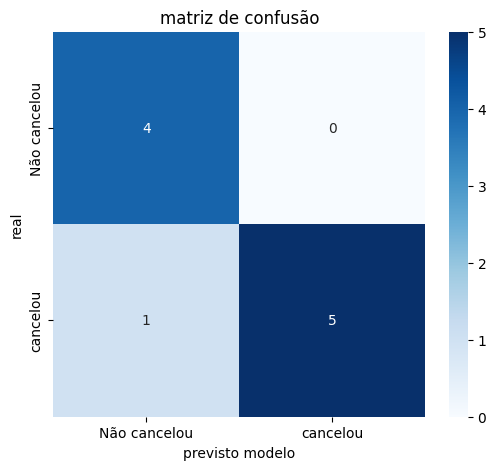

In [ ]:
cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não cancelou', 'cancelou'],
            yticklabels=['Não cancelou', 'cancelou']
            )
plt.title('matriz de confusão')
plt.xlabel('previsto modelo')
plt.ylabel('real')
plt.show()

### Curva ROC (Receiver Operating Characteristic) e AUC (Area Under the Curve)

A Curva ROC e o valor AUC são métricas importantes para avaliar o desempenho de modelos de classificação binária, especialmente quando as classes estão desbalanceadas. O AUC mede a capacidade do modelo de distinguir entre as classes, onde um valor mais próximo de 1 indica um modelo melhor. Uma linha diagonal representa um classificador aleatório (AUC = 0.5).

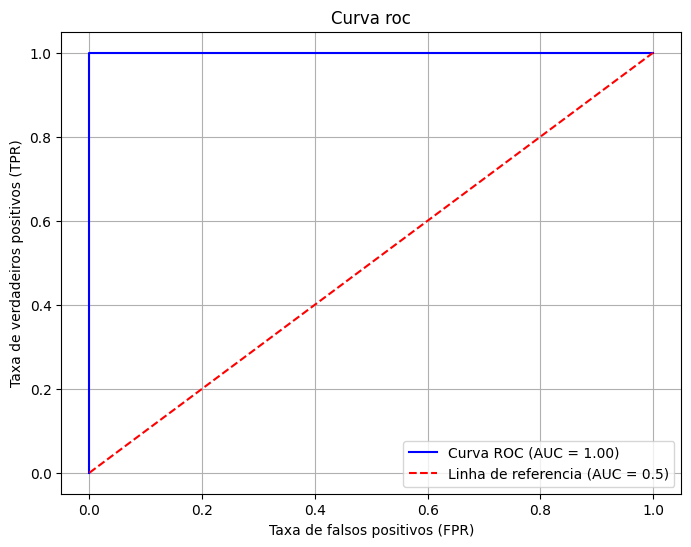

In [ ]:
# obter as probabilidades de previsão para a classe positiva
y_pred_proba = model.predict_proba(X_treino_final)[:, 1]

# calcular a curva roc
fpr, tpr, thresholds = roc_curve(y_treino, y_pred_proba)

# calcular o vlaor auc
auc_score = roc_auc_score(y_treino, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Linha de referencia (AUC = 0.5)')
plt.xlabel('Taxa de falsos positivos (FPR)')
plt.ylabel('Taxa de verdadeiros positivos (TPR)')
plt.title('Curva roc')
plt.legend()
plt.grid(True)
plt.show()

# 6. Predicao com dados novos

### 6.1 Pré-processar os novos dados usando os mesmos steps de treino

In [ ]:
# 1. Simular novos dados (clientes fictícios)
novos_clientes_df = pd.DataFrame({
    'meses_contrato': [5, 1, 20, 3, 15],
    'reclamacoes_suporte': [3, 5, 0, 4, 1],
    'atrasos_pagamento': [1, 2, 0, 1, 0],
    'tipo_plano': ['Cabo', 'Satélite', 'Fibra', 'Cabo', 'Fibra']
})

print("Novos clientes para previsão:")
novos_clientes_df.head()

Novos clientes para previsão:


,meses_contrato,reclamacoes_suporte,atrasos_pagamento,tipo_plano
0,5,3,1,Cabo
1,1,5,2,Satélite
2,20,0,0,Fibra
3,3,4,1,Cabo
4,15,1,0,Fibra


In [ ]:
# modelagem dos novos dados

novos_clientes_numericos_df = novos_clientes_df.select_dtypes(include=['int64', 'float64'])

# encoding das variaveis categoricas
novos_clientes_encoded = encoder.transform(novos_clientes_df[['tipo_plano']])

# converter em um dataframe
novos_clientes_encodeded_df = pd.DataFrame(novos_clientes_encoded, columns=nomes_colunas, index=novos_clientes_df.index)


#juntar as colunas numericas com as categoricas codificadas
novos_clientes_final = novos_clientes_numericos_df.join(novos_clientes_encodeded_df)

# dataframe final pronto para teste
novos_clientes_final.head()

,meses_contrato,reclamacoes_suporte,atrasos_pagamento,tipo_plano_Cabo,tipo_plano_Fibra,tipo_plano_Satélite
0,5,3,1,1.0,0.0,0.0
1,1,5,2,0.0,0.0,1.0
2,20,0,0,0.0,1.0,0.0
3,3,4,1,1.0,0.0,0.0
4,15,1,0,0.0,1.0,0.0


### 6.2 Previsões com novos dados reais

In [ ]:
# gerando as previsoes
previsoes = model.predict(novos_clientes_final)
previsoes_proba = model.predict_proba(novos_clientes_final)[:, 1]

# apresentar os resultados
novos_clientes_df['previsao_cancelamento'] = previsoes
novos_clientes_df['probabilidade_cancelamento'] = previsoes_proba

novos_clientes_df.head(5)

,meses_contrato,reclamacoes_suporte,atrasos_pagamento,tipo_plano,previsao_cancelamento,probabilidade_cancelamento
0,5,3,1,Cabo,1,1.0
1,1,5,2,Satélite,1,1.0
2,20,0,0,Fibra,0,0.0
3,3,4,1,Cabo,1,1.0
4,15,1,0,Fibra,0,0.0


# 7.Deploy (implementar o modelo)

O deploy é a etapa em que o modelo treinado é disponibilizado para uso em um ambiente de produção. Isso significa que ele pode receber novos dados e retornar previsões em tempo real ou em lotes. Existem diversas formas de realizar o deploy, desde APIs RESTful até integrações diretas em sistemas.

Para demonstrar um exemplo conceitual, podemos pensar em como um modelo seria exposto via uma API simples, como com o framework Flask em Python. Em um ambiente de produção real, isso envolveria servidores, orquestradores de contêineres (como Kubernetes) e serviços de nuvem (como Google Cloud AI Platform, AWS SageMaker, Azure ML).

In [ ]:
import json
from flask import Flask, request, jsonify

# Simulação de um aplicativo Flask para deploy
app = Flask(__name__)

# Endpoint para fazer previsões
@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json(force=True)

    # 1. Converter os novos dados recebidos para DataFrame
    new_data_df = pd.DataFrame([data])

    # 2. Pré-processar os novos dados (usar os mesmos steps de treino)
    # Separar colunas numéricas e categóricas
    new_data_numeric_df = new_data_df.select_dtypes(include=['int64', 'float64'])

    # Imputar valores nulos, se houver (usando o imputer já ajustado no treino)
    # new_data_numeric_imputed = imputer.transform(new_data_numeric_df)
    # new_data_numeric_imputed_df = pd.DataFrame(new_data_numeric_imputed, columns=numeric_cols, index=new_data_df.index)

    # Encoding das variáveis categóricas (usando o encoder já ajustado no treino)
    new_data_encoded = encoder.transform(new_data_df[['tipo_plano']])
    new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=nomes_colunas, index=new_data_df.index)

    # Juntar as colunas numéricas e as colunas categóricas codificadas
    # Para simplicidade, vamos usar o new_data_numeric_df diretamente, assumindo que já está tratado ou que o imputer foi aplicado
    new_data_final = new_data_numeric_df.join(new_data_encoded_df)

    # 3. Fazer a previsão
    prediction = model.predict(new_data_final)[0]
    prediction_proba = model.predict_proba(new_data_final)[:, 1][0]

    return jsonify({
        'prediction_churn': int(prediction),
        'probability_churn': float(prediction_proba)
    })

# Simular como os dados seriam enviados para a API
# Note: Para rodar um servidor Flask de verdade, você precisaria de um ambiente diferente do Colab.
# Este é apenas um exemplo conceitual de como a API receberia e processaria os dados.

# Exemplo de como usar a "API" (simulado)
simulated_new_client = {
    'meses_contrato': 7,
    'reclamacoes_suporte': 4,
    'atrasos_pagamento': 2,
    'tipo_plano': 'Cabo'
}

# Converter para o formato que a API espera (JSON)
# Em um cenário real, você faria uma requisição HTTP POST para o endpoint /predict
# Aqui, vamos simular a chamada da função de previsão diretamente com os dados preparados.

# Preparando os dados como a API faria internamente para um único cliente
simulated_df = pd.DataFrame([simulated_new_client])
simulated_numeric = simulated_df.select_dtypes(include=['int64', 'float64'])
simulated_encoded = encoder.transform(simulated_df[['tipo_plano']])
simulated_encoded_df = pd.DataFrame(simulated_encoded, columns=nomes_colunas, index=simulated_df.index)
simulated_final = simulated_numeric.join(simulated_encoded_df)

simulated_prediction = model.predict(simulated_final)[0]
simulated_proba = model.predict_proba(simulated_final)[:, 1][0]

print(f"\nSimulação de Previsão para o Cliente: {simulated_new_client}")
print(f"Previsão de Churn: {simulated_prediction}")
print(f"Probabilidade de Churn: {simulated_proba:.2f}")


Simulação de Previsão para o Cliente: {'meses_contrato': 7, 'reclamacoes_suporte': 4, 'atrasos_pagamento': 2, 'tipo_plano': 'Cabo'}
Previsão de Churn: 1
Probabilidade de Churn: 1.00


# 8. Monitoramento do Modelo

Após o deploy, o monitoramento é crucial para garantir que o modelo continue a performar bem em produção. Modelos podem "degradar" com o tempo devido a mudanças nos dados (drift de dados) ou mudanças no comportamento do target (drift de conceito). O monitoramento envolve coletar métricas de desempenho e de dados, e alertar quando certos limites são excedidos.

**Pontos chave para monitoramento:**
*   **Monitoramento de Desempenho:** Acompanhar a acurácia, precisão, recall, F1-score, AUC ao longo do tempo usando dados com rótulo (quando disponíveis).
*   **Monitoramento de Dados (Data Drift):** Verificar se a distribuição das features de entrada mudou significativamente em comparação com os dados de treino. Isso pode indicar que o modelo está recebendo dados diferentes daqueles para os quais foi otimizado.
*   **Monitoramento de Conceito (Concept Drift):** Ocorre quando a relação entre as features de entrada e a variável alvo muda. O modelo pode estar recebendo os mesmos dados, mas o "significado" ou a resposta esperada para esses dados mudou.
*   **Latência e Erros:** Monitorar o tempo de resposta da API do modelo e a ocorrência de erros.

Aqui está um exemplo conceitual de como o monitoramento de data drift poderia ser visualizado:


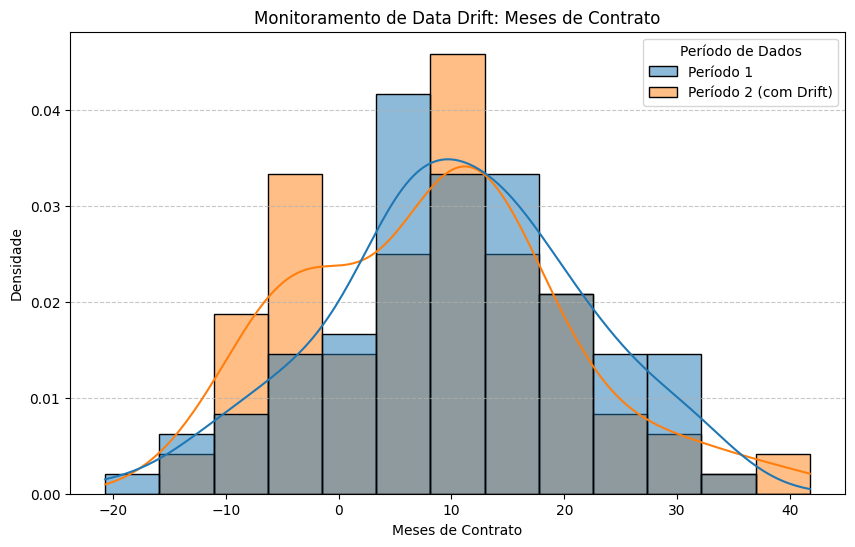

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Simular coleta de dados de produção ao longo do tempo
np.random.seed(42)

# Dados de treino (usaremos as estatísticas do X_treino_final)
mean_meses_contrato_train = X_treino_final['meses_contrato'].mean()
std_meses_contrato_train = X_treino_final['meses_contrato'].std()

# Simular dados de produção para 'meses_contrato' nos primeiros meses (distribuição similar)
production_data_period1 = np.random.normal(mean_meses_contrato_train, std_meses_contrato_train, 100)

# Simular dados de produção para 'meses_contrato' em um período posterior (com drift)
# Por exemplo, novos clientes com menos meses de contrato em média
production_data_period2 = np.random.normal(mean_meses_contrato_train * 0.7, std_meses_contrato_train, 100)

# Criar um DataFrame para visualização
monitoring_df = pd.DataFrame({
    'meses_contrato': np.concatenate([production_data_period1, production_data_period2]),
    'periodo': ['Período 1'] * 100 + ['Período 2 (com Drift)'] * 100
})

plt.figure(figsize=(10, 6))
ax = sns.histplot(data=monitoring_df, x='meses_contrato', hue='periodo', kde=True, stat='density', common_norm=False)
plt.title('Monitoramento de Data Drift: Meses de Contrato')
plt.xlabel('Meses de Contrato')
plt.ylabel('Densidade')
# Get the legend from the axes and set its title
if ax.legend_ is not None:
    ax.legend_.set_title('Período de Dados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Além do drift de dados, você monitoraria o desempenho do modelo em relação ao target real
# (se disponível) para detectar concept drift ou degradação geral de desempenho.
# Exemplo conceitual: Média de probabilidade de churn ao longo do tempo
# Supondo que você tem uma coluna 'data_previsao' e 'probabilidade_churn' de cada previsão
# historic_predictions_df.groupby('data_previsao').agg(avg_proba=('probabilidade_churn', 'mean')).plot()